# GPU Experiment 1: Layer-wise Probing
This notebook evaluates steering vectors across layers 4 to 15 to empirically validate the selection of Layer 8.

In [1]:
!pip install -q -U transformers accelerate bitsandbytes evaluate bert_score matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 32.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires goo

In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from evaluate import load
from tqdm import tqdm

model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
)
bertscore = load("bertscore")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [3]:
# Load data
with open('/kaggle/input/datasets/anhemgithom/vnese-data/vietnamese_medical_halueval_15k_specialized.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Sample 200 for vector extraction, 100 for evaluation (for speed)
np.random.seed(42)
extract_data = np.random.choice(data, 200, replace=False)
eval_data = np.random.choice([d for d in data if d not in extract_data], 100, replace=False)

def format_prompt(q):
    messages = [
        {"role": "system", "content": "You are a helpful and accurate medical assistant."},
        {"role": "user", "content": q}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


In [4]:
def extract_vector(layer_idx):
    pos_acts, neg_acts = [], []
    
    def hook_fn(module, input, output):
        return output
    
    hook = model.model.layers[layer_idx].register_forward_hook(hook_fn)
    
    for item in tqdm(extract_data, desc=f"Extracting L{layer_idx}"):
        prompt = format_prompt(item['question'])
        pos_text = prompt + item.get('right_answer', item.get('positive_answer'))
        neg_text = prompt + item['hallucinated_answer']
        
        for t, lst in [(pos_text, pos_acts), (neg_text, neg_acts)]:
            inputs = tokenizer(t, return_tensors="pt").to(model.device)
            with torch.no_grad():
                out = model(**inputs, output_hidden_states=True)
                lst.append(out.hidden_states[layer_idx][0, -1, :].float().cpu().numpy())
    
    hook.remove()
    pos_mean = np.mean(pos_acts, axis=0)
    neg_mean = np.mean(neg_acts, axis=0)
    vec = pos_mean - neg_mean
    vec = vec / np.linalg.norm(vec)
    return torch.tensor(vec, dtype=torch.float16, device=model.device)


In [5]:
def evaluate_layer(layer_idx, vec, alpha=18.0, K=16):
    step_counter = [0]
    def steering_hook(module, input, output):
        step_counter[0] += 1
        t = step_counter[0]
        if t <= K:
            alpha_t = alpha * (1.0 - (t - 1) / K)
            if isinstance(output, tuple):
                h = output[0]
                v = vec.to(device=h.device, dtype=h.dtype)
                h[:, -1, :] += alpha_t * v
                return (h,) + output[1:]
            else:
                v = vec.to(device=output.device, dtype=output.dtype)
                output[:, -1, :] += alpha_t * v
                return output
        return output

    hook_handle = model.model.layers[layer_idx].register_forward_hook(steering_hook)
    
    generated = []
    refs = []
    for item in tqdm(eval_data, desc=f"Evaluating L{layer_idx}"):
        step_counter[0] = 0 # Reset đếm bước cho từng câu hỏi mới
        prompt = format_prompt(item['question'])
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=100, do_sample=False, pad_token_id=tokenizer.pad_token_id)
        
        gen_text = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        generated.append(gen_text)
        refs.append(item.get('right_answer', item.get('positive_answer')))
        
    hook_handle.remove()
    
    res = bertscore.compute(predictions=generated, references=refs, model_type="bert-base-multilingual-cased")
    return np.mean(res['f1'])


Evaluating L4: 100%|██████████| 100/100 [11:18<00:00,  6.79s/it]


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Layer 13 BERTScore F1: 0.7108


Evaluating L14: 100%|██████████| 100/100 [11:56<00:00,  7.16s/it]


Layer 14 BERTScore F1: 0.7134


Evaluating L15: 100%|██████████| 100/100 [12:03<00:00,  7.24s/it]


Layer 15 BERTScore F1: 0.7098


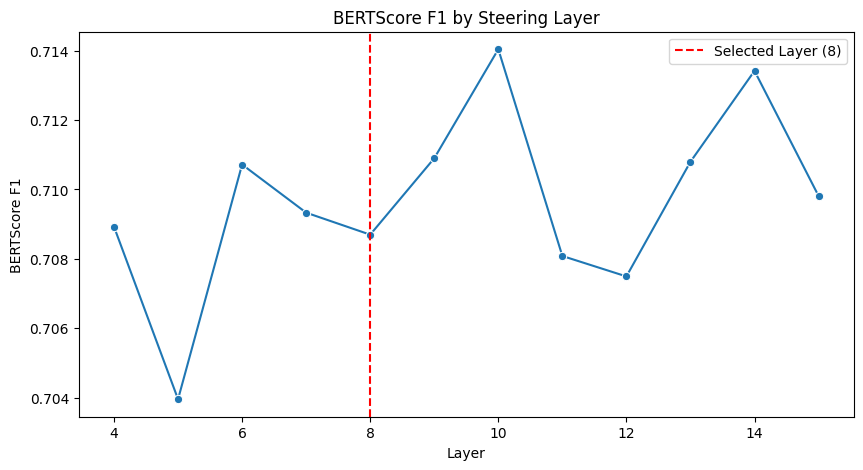

In [6]:
results = {}
layers_to_test = list(range(4, 16))

for l in layers_to_test:
    vec = extract_vector(l)
    f1 = evaluate_layer(l, vec)
    results[l] = f1
    print(f"Layer {l} BERTScore F1: {f1:.4f}")

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=list(results.keys()), y=list(results.values()), marker='o')
plt.title("BERTScore F1 by Steering Layer")
plt.xlabel("Layer")
plt.ylabel("BERTScore F1")
plt.axvline(x=8, color='r', linestyle='--', label='Selected Layer (8)')
plt.legend()
plt.savefig("layer_probing_results.png")
plt.show()

with open("layer_probing_results.json", "w") as f:
    json.dump(results, f)
